<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/mini_labs/week_6_kldiv.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# BYU CS 473 — KL Divergence

In this assignment, you will learn the basics of **Kullback–Leibler (KL) divergence**. KL divergence measures how one probability distribution differs from another.

---

## Learning Goals
- Understand the definition of KL divergence  
- Compute KL divergence between two Gaussian distributions  
- Understand why KL divergence is always non-negative  
- Relate KL divergence to Maximum Likelihood Estimation (MLE)  
- Compare forward vs reverse KL divergence


### Exercise 1
In your own words, explain what KL divergence measures.  
Give a real-world analogy (e.g., communication, language modeling).


KL divergence is a way of generalizing what we do every day to probability distributions.

Every day, we judge between what the right answer is on a problem set or test and what we wrote. We assign points and subtract them as the difference between our answer and the truth grows. We have effectively scoring of discrete objects.

KL divergence generalizes this to not separate by individual point sections, but to look at the assignment as a whole. It also is continuous, so we feed in a whole assignment with a whole truth and it gives us a positive scalar score of how different these things are.

## 2. Example: KL Divergence Between Two Gaussians

If $P = \mathcal{N}(\mu_p, \sigma_p^2)$ and $Q = \mathcal{N}(\mu_q, \sigma_q^2)$, the KL divergence is:

$D_{\text{KL}}(P \,\|\, Q) = \log \frac{\sigma_q}{\sigma_p} + \frac{\sigma_p^2 + (\mu_p - \mu_q)^2}{2\sigma_q^2} - \frac{1}{2}$


In [1]:
import numpy as np

def kl_gaussian(mu_p, sigma_p, mu_q, sigma_q):
    return np.log(sigma_q/sigma_p) + (sigma_p**2 + (mu_p - mu_q)**2)/(2*sigma_q**2) - 0.5

# Example
print("KL(P||Q) with mu_p=0, sigma_p=1, mu_q=1, sigma_q=2:")
kl_gaussian(0, 1, 1, 2)




KL(P||Q) with mu_p=0, sigma_p=1, mu_q=1, sigma_q=2:


np.float64(0.4431471805599453)

### Exercise 2
- Compute ${\text{KL}}(P \,\|\, Q)$ for several pairs of Gaussian distributions.  
- Which matters more: differences in mean, or differences in variance?  
- Plot ${\text{KL}}(P \,\|\, Q)$ as $μ_q$ varies from -3 to 3, holding σ fixed.


In [3]:
import numpy as np

# Define pairs of (mu_p, sigma_p, mu_q, sigma_q) for KL divergence calculation
kl_pairs_params = [
    (0, 1, 0, 2),  # P=N(0,1), Q=N(0,2) - variance difference
    (0, 1, 1, 1),  # P=N(0,1), Q=N(1,1) - mean difference
    (0, 1, 0, 1)   # P=N(0,1), Q=N(0,1) - identical distributions
]

KL_div_results = []
for mu_p, sigma_p, mu_q, sigma_q in kl_pairs_params:
    kl = kl_gaussian(mu_p, sigma_p, mu_q, sigma_q)
    KL_div_results.append(f"KL(N({mu_p},{sigma_p**2}) || N({mu_q},{sigma_q**2})) = {kl:.4f}")

for result in KL_div_results:
    print(result)

# To answer the question "Which matters more: differences in mean, or differences in variance?"
# We can add more specific examples:
print("\nComparing impact of mean vs variance differences:")
kl_mean_diff = kl_gaussian(0, 1, 0.5, 1) # P=N(0,1), Q=N(0.5,1) (mean diff: 0.5)
kl_var_diff = kl_gaussian(0, 1, 0, 1.5) # P=N(0,1), Q=N(0,1.5) (std dev diff: 0.5, variance diff: 1.25)
print(f"KL(N(0,1) || N(0.5,1)) (mean diff only) = {kl_mean_diff:.4f}")
print(f"KL(N(0,1) || N(0,1.5)) (variance diff only) = {kl_var_diff:.4f}")


KL(N(0,1) || N(0,4)) = 0.3181
KL(N(0,1) || N(1,1)) = 0.5000
KL(N(0,1) || N(0,1)) = 0.0000

Comparing impact of mean vs variance differences:
KL(N(0,1) || N(0.5,1)) (mean diff only) = 0.1250
KL(N(0,1) || N(0,1.5)) (variance diff only) = 0.1277


It looks here like impact of mean is slightly more impactful, even when the movement of the mean is only 50% of the standard deviation.

This suggests that if the mean is moving by x, KL decreases more than if the std is moving by x.

## 3. Non-Negativity of KL Divergence

**Gibbs’ Inequality**:  
$D_{\text{KL}}(P \,\|\, Q) \geq 0$

with equality if and only if $P = Q$.  
This means the "distance" is never negative.

Intuition: if you approximate $P$ with $Q$, you can never do better than the true distribution.


In [4]:
# Quick numerical experiment
p = np.array([0.4, 0.6])
q = np.array([0.5, 0.5])
kl = np.sum(p * np.log(p/q))
kl


np.float64(0.020135513550688863)

### Exercise 3
- Construct two different discrete distributions $P$ and $Q$.  
- Compute ${\text{KL}}(P \,\|\, Q)$ and ${\text{KL}}(Q \,\|\, P)$.  
- Verify that both are ≥ 0.  
- When do you get $\text{KL} = 0$?


## 1. Definition

For discrete distributions:

$D_{\text{KL}}(P \,\|\, Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}$

For continuous distributions:

$D_{\text{KL}}(P \,\|\, Q) = \int p(x) \log \frac{p(x)}{q(x)} dx$

- KL divergence is **not symmetric**: $D_{\text{KL}}(P \,\|\, Q) \neq D_{\text{KL}}(Q \,\|\, P)$
- KL divergence is **not a distance metric**, but it measures how well $Q$ approximates $P$.  


In [20]:
p = np.array([[1,1,5,7,9],
              [2,2,3,2,4],
              [3,3,0,0,8],
              [4,2,3,6,7],
              [1,2,3,4,5]]
             )
q = np.array([[6,3,9,4,5],
              [1,5,8,5,9],
              [8,6,99,2,6],
              [47,72,73,76,77],
              [1,2,3,4,5]]
              )
p = p/np.sum(p)
q = q/np.sum(q)
p_x = np.sum(p, axis=0)
q_x = np.sum(q, axis=0)

#lets do this the numpy way. it's much faster.


def kl_discrete(p,q):
  return  (
      np.sum(p*np.log(p/q))
      )


print(f'p = \n {p_x}')
print(f'q = \n{q_x}')

print(f'kl_divergence(p,q) = {kl_discrete(p_x,q_x)}')
print(f'kl_divergence(q,p) = {kl_discrete(q_x,p_x)}')
print(f'kl_divergence(p,q) = {kl_discrete(q_x,q_x)}')






p = 
 [0.12643678 0.11494253 0.16091954 0.2183908  0.37931034]
q = 
[0.11753731 0.1641791  0.35820896 0.16977612 0.19029851]
kl_divergence(p,q) = 0.15610389152211948
kl_divergence(q,p) = 0.1625875114727401
kl_divergence(p,q) = 0.0


We have shown above in a very circumlocutious way (by constructing a bivariate distribution then marginalizing them to become univariates) that kl(p,q) != kl(q,p), and that the way to getkl==0 is by calculating kl(x,x) where x is any distribution.

## 4. KL Divergence and Maximum Likelihood Estimation

Suppose data is generated from distribution P, and we fit model Qθ.  

- MLE maximizes likelihood:   
  $\theta^* = \arg \max_\theta \sum \log q_\theta(x_i)$
- Equivalent to minimizing:  
  $D_{\text{KL}}(P \,\|\, Q_\theta)$

Thus, **MLE is KL minimization**: we make our model Qθ as close as possible to the true distribution P.


### Exercise 4
Explain in your own words:
- Why minimizing ${\text{KL}}(P \,\|\, Q)$ is the same as maximizing likelihood.  
- Why this interpretation helps us understand model training.


max likelihood estimation is essentially finding the dist that had the greatest probability of producing the data observed. That should be very intuitively the "shape" of the data.

As it turns out, that is more directly what KL is calculating. The difference between the shapes (and location) of the distributions

I think that interpreting MLE as KL divergence is good because it is a step away from "finding true parameters" and a step toward matching the shape of the data, or the shape of reality. We can literally score how accurately we reproduced the shape of reality. That's what models are meant to do, anyways!

## 5. Forward vs Reverse KL

- **Forward KL:** $D_{\text{KL}}(P \,\|\, Q)$  
  - Penalizes missing modes ($Q$ must cover all support of $P$).  
  - "Mode covering."

- **Reverse KL:** $D_{\text{KL}}(Q \,\|\, P)$  
  - Penalizes putting mass where $P$ has none.  
  - "Mode seeking."

This asymmetry explains why different algorithms (e.g. variational inference vs expectation propagation) behave differently.


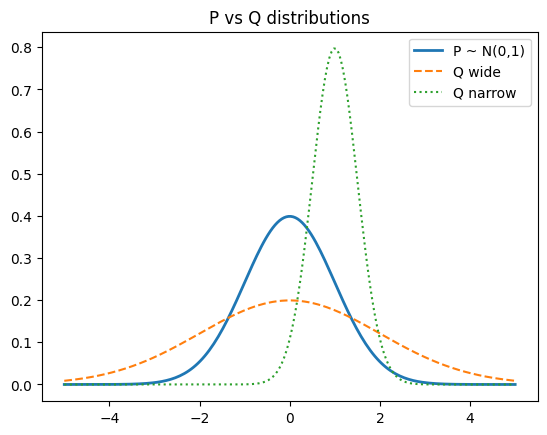

In [21]:
import matplotlib.pyplot as plt
import scipy.stats as stats

x = np.linspace(-5, 5, 200)
p = stats.norm(0, 1).pdf(x)   # true distribution
q1 = stats.norm(0, 2).pdf(x)  # wide Q
q2 = stats.norm(1, 0.5).pdf(x) # narrow Q

plt.plot(x, p, label="P ~ N(0,1)", linewidth=2)
plt.plot(x, q1, label="Q wide", linestyle="--")
plt.plot(x, q2, label="Q narrow", linestyle=":")
plt.legend()
plt.title("P vs Q distributions")
plt.show()


### Exercise 5
1. Compute both ${\text{KL}}(P \,\|\, Q)$ and ${\text{KL}}(Q \,\|\, P)$ for $P=N(0,1)$, $Q=N(1,0.5)$.  
2. Which is larger? Why?  
3. In which case would forward KL be more appropriate? Reverse KL?


In [23]:
p_q = (0,1,1,0.5)
q_p = (1,0.5,0,1)

print(f'kl(p,q) = {kl_gaussian(0,1,1,0.5)}')

print(f'kl(q,p) = {kl_gaussian(1,0.5,0,1)}')


kl(p,q) = 2.8068528194400546
kl(q,p) = 0.8181471805599454


We see here that kl(p,q) is much larger than kl(q,p).

I think that the reason that kl(p,q) > kl(q,p) is that when most of the divergence occurs, q is already at zero and we are weighting by q. Therefore, the divergence metric won't pick anything up.

but kl(p,q) is weighted by p. This makes it so that part of the graph (basically around 0) is still HEAVILY weighted, and it increases the divergence score significantly.

I think that in the case where we need to match everything because missing a point in the true distribution is catastrophic would be a forward KL. Imagine a cluster of data in the true dataset for cancer imaging. Wouldn't want to miss that.

Reverse KL could be if we want to maximize something that doesn't depend on the center of mass. If there are two "hot spots" where we could throw a ball into to score points, but we realistically only need to score in one hoop, using reverse KL would make it so our parameters center on one distribution and we end up scoring more by not splitting the difference. In this analogy, "shooting the ball" would be modeled as a random variable (via jitter).

## 6. Reflection

### Exercise 6
Answer in 2–3 sentences each:

1. Why is KL divergence always non-negative?  
2. How does KL divergence connect to MLE?  
3. Why do forward and reverse KL behave differently?  


1) KL divergence is always non-negative because we are weighting by what is on top of the log. The numerator is going to be maximized when the weight is maximized. This is the positive component of the formula. But it is not guaranteed that the denominator is maximized while the weight is maximized. This gives us a more "rectangular" area instead of a "square" one, so integrating through the entire x will end up will a smaller negative component (coming from rules of logs in fractions).

2)
KL divergence allows us to minimize the difference between two distributions. If the distributions are empirical data and a hypothetical model, we genereally use MLE to find the best fit. But we can also use KL divergence to find the lowest-divergent model and end up finding the exact same best model.They do the same thing when we put them into the same framework of problem.

3)
Forward and reverse KL have different weighting schemes. If the weight is 0 at a specific x location, then it doesn't matter how different the probability masses are at that point, because it is multiplied by 0 before getting summed in with everything else. So reverse vs forward will change WHERE divergence actually matters (makes it into the final KL divergence sum)